<a href="https://colab.research.google.com/github/davidlealo/tarea_1_sisrec_2026/blob/main/TAREA_1b_SICREC_G26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 Sistemas de Recomendación
### Tarea 26


*   Marcelo Vargas
*   David Leal





In [ ]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO

# Variable para URLs
BASE_URL = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/"

def get_url(file_name):
    return f"{BASE_URL}{file_name}"


df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                           names=['user_id', 'artist_id', 'rating'], header=None)
df_artists = pd.read_csv(get_url("ydata_artists.txt"), sep='\t',
                         names=['artist_id', 'artist_name', 'genre'], header=None)

df_train_wiki = pd.read_csv(get_url("wikimedia_train.csv"))
df_val_wiki = pd.read_csv(get_url("wikimedia_validation.csv"))


def load_remote_npy(file_name):
    response = requests.get(get_url(file_name))
    return np.load(BytesIO(response.content), allow_pickle=True)

image_embeddings = load_remote_npy("wikimedia_image_embeddings.npy")
item_id_to_idx = load_remote_npy("wikimedia_item_id_to_idx.npy").item()

print("¡Datos cargados exitosamente!")

In [2]:
!pip uninstall -y numpy
!pip install numpy==1.26

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 122.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version 

# Error con la versióin de numpy y solución

Estuve hablando con Gemini (https://gemini.google.com/share/0593148d28a8) y al bajar la versión de Numpy para usar Surprise hay problemas con algunos archivos, entonces estoy armando otra versión de este código solamente con los temas de Yahoo Music

In [1]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO

# Variable para URLs
BASE_URL = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/"

def get_url(file_name):
    return f"{BASE_URL}{file_name}"


df_train_music = pd.read_csv(get_url("ydata_train.txt"), sep='\t',
                             names=['user_id', 'artist_id', 'rating'], header=None)
df_val_music = pd.read_csv(get_url("ydata_val.txt"), sep='\t',
                           names=['user_id', 'artist_id', 'rating'], header=None)
df_artists = pd.read_csv(get_url("ydata_artists.txt"), sep='\t',
                         names=['artist_id', 'artist_name', 'genre'], header=None)



def load_remote_npy(file_name):
    response = requests.get(get_url(file_name))
    return np.load(BytesIO(response.content), allow_pickle=True)


print("¡Datos cargados exitosamente de Música!")

¡Datos cargados exitosamente de Música!


## Análisis del set de datos: `df_artists`
Para analizar esto analizaré primero la cantidad de artístas únicos y géneros únicos, además de contar la cantidad de géneros distintos


In [ ]:
artistas_unicos = df_artists['artist_id'].nunique()
print("Cantidad de artistas únicos:", artistas_unicos)

Cantidad de artistas únicos: 2631


In [ ]:
generos_musicales_unicos = df_artists['genre'].nunique()
print("Cantidad de géneros únicos:", generos_musicales_unicos)

Cantidad de géneros únicos: 15


In [ ]:
generos_musicales = df_artists['genre'].value_counts()
generos_musicales

,count
genre,
rock,773
electronic,693
pop,244
folk,222
country,177
punk,145
metal,107
hiphop,68
jazz,51


In [ ]:
import matplotlib.pyplot as plt

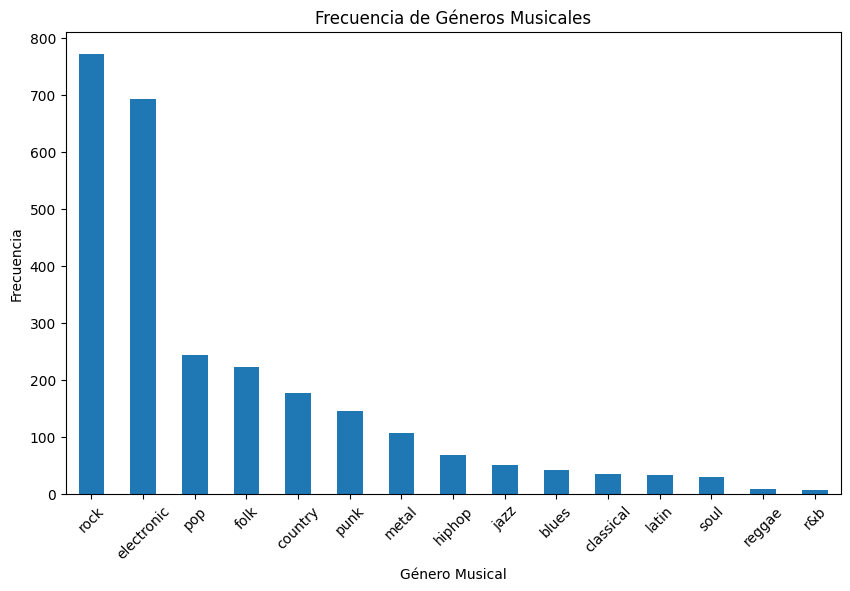

In [ ]:
generos_musicales.plot(kind='bar', figsize=(10, 6))
plt.title('Frecuencia de Géneros Musicales')
plt.xlabel('Género Musical')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_artists

,artist_id,artist_name,genre
0,1000004,'Til Tuesday,electronic
1,1000006,.38 Special,pop
2,1000012,"10,000 Maniacs",metal
3,1000023,10cc,electronic
4,1000026,112,electronic
...,...,...,...
2626,1099513,The Darkness,metal
2627,1099605,The Sleepy Jackson,folk
2628,1099693,The Thrills,rock
2629,1100044,Beloved [US],pop


Tenemos un total de `2631` artistas distintos y solamente `15` géneros musicales diferentes. Los que tienen mayor frecuencia en nuestra bbdd es `rock`	con `773`, `electronic` con	`693`, `pop` con `244` y `folk`con	`222`. Los otros géneros musicales tienen menos de `200` observaciones, siendo los que tienen frecuencias menores los  géneros de `soul` con	`29`, `reggae` con	`8`y `r&b`	con `6`. Me llamó mucho la atención que `latin` también tenga poco más de 30 observaciones.

## Análisis del set de datos: `df_train_music`

Lo primero que realizaré es como ya está cargada la bbdd es ver la configuración de los datos y si tenemos algunos faltantes o transformaciones que puedan ser necesarias

In [ ]:
df_train_music

,user_id,artist_id,rating
0,643947,1098682,62
1,784415,1068684,0
2,595120,1024523,100
3,1270239,1021824,0
4,735673,1019857,0
...,...,...,...
534632,1248788,1001649,0
534633,103798,1006535,0
534634,1248788,1013581,10
534635,1248788,1016358,14


In [ ]:
df_train_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534637 entries, 0 to 534636
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    534637 non-null  int64
 1   artist_id  534637 non-null  int64
 2   rating     534637 non-null  int64
dtypes: int64(3)
memory usage: 12.2 MB


In [ ]:
df_train_music.isnull().sum()

,0
user_id,0
artist_id,0
rating,0


Con esto confirmamos la cantidad de datos, tenemos id de usuarios, id de artistas y rating. Tenemos un total de 534637 por columna en el DF y no tenemos datos nulos en `df_train_music`



In [ ]:
df_train_music.describe()

,user_id,artist_id,rating
count,5.346370e+05,5.346370e+05,534637.000000
mean,9.514221e+05,1.030821e+06,19.771927
std,5.609952e+05,2.839402e+04,34.829398
min,1.430000e+02,1.000004e+06,0.000000
25%,4.681470e+05,1.011139e+06,0.000000
50%,9.454190e+05,1.022601e+06,0.000000
75%,1.429002e+06,1.036736e+06,30.000000
max,1.948075e+06,1.100995e+06,255.000000


In [ ]:
df_train_music['rating'].unique()

array([ 62,   0, 100,  40,  30,  56, 255,  70,  50,  59,  28,  46,  20,
        10,   2,  38,  90,  23,  78,  85,   1,  80,  21,  47,  72,   5,
        97,  60,  92,  48,  71,   4,   7,  32,  88,  67,  79,  83,   6,
        82,  39,   3,  19,  87,  69,   8,  74,  75,  84,  36,  89,  35,
        18,  45,  65,  22,  27,  15,  91,  16,  12,  43,  76,  26,  41,
        86,   9,  64,  49,  68,  95,  37,  58,  55,  96,  14,  13,  61,
        63,  53,  25,  24,  17,  34,  66,  73,  81,  52,  57,  42,  54,
        94,  44,  51,  31,  93,  77,  11,  98,  99,  29,  33])

In [ ]:
rating_counts = df_train_music['rating'].value_counts().sort_index()
rating_counts

,count
rating,
0,334327
1,4530
2,1312
3,859
4,1112
...,...
97,127
98,428
99,169


In [ ]:
534637 - 334327

200310

In [ ]:
334327/534637

0.6253345728036032

In [ ]:
numero_users = df_train_music['user_id'].nunique()
numero_users

2549

In [ ]:
numero_artistas = df_train_music['artist_id'].nunique()
numero_artistas

2631

In [ ]:
todos_artistas_ids = set(df_train_music['artist_id'].unique())

artistas_con_ratings = set(df_train_music['artist_id'].unique())

artistas_no_ratings = todos_artistas_ids - artistas_con_ratings

print(f"Total artistas en catálogo: {len(todos_artistas_ids)}")
print(f"Artistas con al menos una evaluación: {len(artistas_con_ratings)}")
print(f"Artistas sin NINGUNA evaluación: {len(artistas_no_ratings)}")

Total artistas en catálogo: 2631
Artistas con al menos una evaluación: 2631
Artistas sin NINGUNA evaluación: 0


In [ ]:
todos_usuarios_ids = set(df_train_music['user_id'].unique())

usuarios_con_ratings = set(df_train_music['user_id'].unique())

usuarios_no_ratings = todos_usuarios_ids - usuarios_con_ratings

print(f"Total usuarios en catálogo: {len(todos_usuarios_ids)}")
print(f"Usuarios con al menos una evaluación: {len(usuarios_con_ratings)}")
print(f"Usuarios sin NINGUNA evaluación: {len(usuarios_no_ratings)}")

Total usuarios en catálogo: 2549
Usuarios con al menos una evaluación: 2549
Usuarios sin NINGUNA evaluación: 0


Los primeros análisis con `df_train_music.describe()`nos muestra que tenemos una gran cantidad de valores en cero, porque en `rating` los valores `min`, `25`y `50`están co valor 0
Luego con `df_train_music['rating'].value_counts().sort_index()`conté cuantos valores tenemos de cada rating único y nos podemos dar cuenta que el valor 0 efectivamente tiene un número importante, este es de un `62.5%` de los valores del dataframe `usuario`, `artista` y `rating`.
Este fenómeno de sparsity significativo es esperable, porque efectivamente los usuarios no consumen todo el catálogo.

El número de usuarios únicos es de 2549 y de artístas únicos es de 2631. De estos todos los artístas y usuarios tienen  evaluaciones.

In [ ]:
artist_popularity = df_train_music['artist_id'].value_counts().reset_index()
artist_popularity.columns = ['artist_id', 'conteo_evaluaciones']

artist_popularity_named = artist_popularity.merge(df_artists, on='artist_id', how='left')

In [ ]:
top_5_mas = artist_popularity_named.head(5)
print("Top 5 Artistas con MÁS evaluaciones")
print(top_5_mas[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MÁS evaluaciones
           artist_name  genre  conteo_evaluaciones
0  Stone Temple Pilots   rock                  383
1         Eric Clapton   rock                  370
2            Foreigner   rock                  363
3               Eagles   rock                  361
4            Metallica  metal                  361


In [ ]:
top_5_menos = artist_popularity_named.tail(5)
print("Top 5 Artistas con MENOS evaluaciones")
print(top_5_menos[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MENOS evaluaciones
           artist_name       genre  conteo_evaluaciones
2626              Snot  electronic                  103
2627        Olga Tanon        folk                  103
2628  Neville Brothers        rock                  102
2629        Tom Lehrer        rock                  100
2630    Steve Ferguson        rock                   98


Con estos dos últimos códigos podemos ver que ningún artísta tiene más de 383 evaluaciones `Stone Temple Pilots` y ninguno menos de 98 `Steve Ferguson`

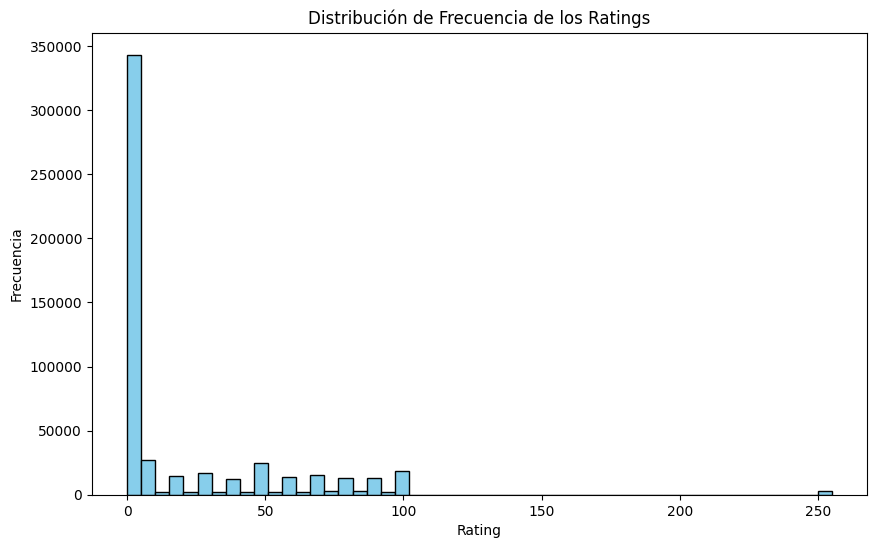

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_train_music['rating'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Frecuencia de los Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
print(np.sort(df_train_music['rating'].unique()))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 255]


In [ ]:
print((df_train_music['rating'] == 255).sum())

2759


In [ ]:
print((df_train_music['rating'] == 100).sum())

17431


In [ ]:
2759/534637

0.0051605107764707645

Con esto me di cuenta que tenemos un valor que parece atípico. Un `0.0051605107764707645%` de los valores tienen un valor 255 que creo no está bien porque el rating parece ser de 0 a 100. Por el momento no voy a tomar una decisión de qué hacer con esos datos, porque todavía no hago el análisis del `df_val_music`

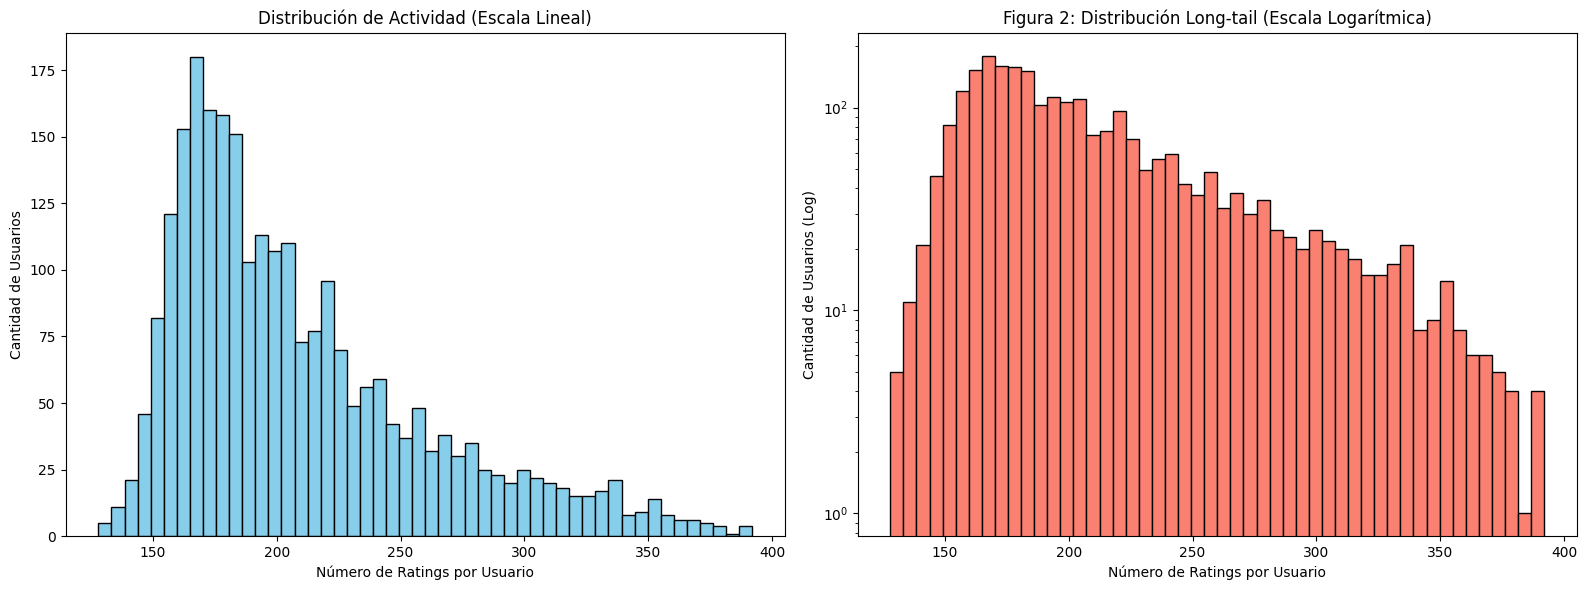

In [ ]:
ratings_por_user = df_train_music['user_id'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(ratings_por_user, bins=50, color='skyblue', edgecolor='black')
ax1.set_title('Distribución de Actividad (Escala Lineal)')
ax1.set_xlabel('Número de Ratings por Usuario')
ax1.set_ylabel('Cantidad de Usuarios')

ax2.hist(ratings_por_user, bins=50, color='salmon', edgecolor='black')
ax2.set_yscale('log')
ax2.set_title('Figura 2: Distribución Long-tail (Escala Logarítmica)')
ax2.set_xlabel('Número de Ratings por Usuario')
ax2.set_ylabel('Cantidad de Usuarios (Log)')

plt.tight_layout()
plt.show()

In [ ]:
# Para la tabla de estadísticas
counts = df_train_music['user_id'].value_counts()

print(f"Promedio de ratings por usuario: {counts.mean():.2f}")
print(f"Máximo de ratings por un solo usuario: {counts.max()}")
print(f"Mínimo de ratings por un solo usuario: {counts.min()}")

Promedio de ratings por usuario: 209.74
Máximo de ratings por un solo usuario: 392
Mínimo de ratings por un solo usuario: 128


Este análisis nos demuestra que tenemos casi `210`evaluaciones promedio por usuarios, con un mínimo de `128`y un máximo de `392`evaluaciones por usuario. Por lo menos en este dataset no parece tener el problema de usuarios con muy pocos rating.

In [ ]:
n_users_train = df_train_music['user_id'].nunique()
n_items_catalogo = df_artists['artist_id'].nunique()
n_ratings_train = len(df_train_music)

densidad_train = (n_ratings_train / (n_users_train * n_items_catalogo)) * 100

items_por_usuario = n_ratings_train / n_users_train

print(f"--- Análisis de Densidad: Entrenamiento ---")
print(f"Usuarios únicos: {n_users_train}")
print(f"Artistas en catálogo: {n_items_catalogo}")
print(f"Total de Ratings: {n_ratings_train}")
print(f"Promedio de artistas evaluados por usuario: {items_por_usuario:.2f}")
print(f"Densidad del Dataset: {densidad_train:.4f}%")

--- Análisis de Densidad: Entrenamiento ---
Usuarios únicos: 2549
Artistas en catálogo: 2631
Total de Ratings: 534637
Promedio de artistas evaluados por usuario: 209.74
Densidad del Dataset: 7.9720%


La densidad de nuestro set de entrenamiento es de `7.9720%` que indica que aunque la matriz es dispersa y tenemos un número importante de sparsity del `62.5%`.

## Análisis del set de datos: `df_val_music`

Como hice antes comenzaré a revisar la estructura de los datos y si tenemos datos faltantes

In [ ]:
df_val_music

,user_id,artist_id,rating
0,1641538,1048320,0
1,1641538,1048942,53
2,1641538,1050886,30
3,930222,1098345,0
4,930222,1020250,0
...,...,...,...
152419,81478,1013119,50
152420,1922878,1009168,20
152421,1711362,1097521,100
152422,1692654,1004539,0


In [ ]:
df_val_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152424 entries, 0 to 152423
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    152424 non-null  int64
 1   artist_id  152424 non-null  int64
 2   rating     152424 non-null  int64
dtypes: int64(3)
memory usage: 3.5 MB


In [ ]:
df_val_music.isnull().sum()

,0
user_id,0
artist_id,0
rating,0


In [ ]:
cantidad_train = 534637
cantidad_val = 152424
total_cantidad_train_val = cantidad_train + cantidad_val
total_cantidad_train_val

687061

In [ ]:
534637/687061

0.7781507027760272

In [ ]:
152424/687061

0.22184929722397284

Verificamos que no tenemos valores nulos y que al igual que el set de entrenaiento las columnas son exactamente las mismas. La distribución es de un `77.8%`de entrenamiento y un `22.2%`de validación.

In [ ]:
df_val_music.describe()

,user_id,artist_id,rating
count,1.524240e+05,1.524240e+05,152424.000000
mean,9.513846e+05,1.030885e+06,19.833051
std,5.609833e+05,2.845525e+04,34.917863
min,1.430000e+02,1.000004e+06,0.000000
25%,4.681470e+05,1.011312e+06,0.000000
50%,9.454190e+05,1.022740e+06,0.000000
75%,1.429002e+06,1.036607e+06,30.000000
max,1.948075e+06,1.100995e+06,255.000000


In [ ]:
df_val_music['rating'].unique()

array([  0,  53,  30,   8,  17,  10,  62,  60,  89,  20, 100,  19,   3,
        50,  11,  70,  94,  36,  26,  85,  64,  80,  25,  90,  40,   1,
        52,  76,   2,  61,  81,  68,  59,  54,  45,  67,  79,  63,  57,
        83,  78,  95,  34,  72,  13,  51,  66,  18,  74,  92,  88, 255,
        29,  91,  84,  55,  56,  49,  98,  21,   4,  41,  12,  96,  47,
         7,  75,  58,  14,  77,  82,  28,  48,  38,  35,  65,  87,   5,
        97,  71,  99,  43,  15,  23,  33,  27,  46,   6,  24,  32,  86,
        16,   9,  42,  93,  69,  39,  22,  44,  37,  73,  31])

In [ ]:
rating_counts_val = df_val_music['rating'].value_counts().sort_index()
rating_counts_val

,count
rating,
0,95223
1,1304
2,378
3,233
4,338
...,...
97,41
98,130
99,44


In [ ]:
cantidad_val - 95223

57201

In [ ]:
95223/cantidad_val

0.6247244528420721

In [ ]:
numero_users_val = df_val_music['user_id'].nunique()
numero_users_val

2549

In [ ]:
numero_artistas_val = df_val_music['artist_id'].nunique()
numero_artistas_val

2631

In [ ]:
todos_artistas_ids_val = set(df_val_music['artist_id'].unique())

artistas_con_ratings_val = set(df_val_music['artist_id'].unique())

artistas_no_ratings_val = todos_artistas_ids_val - artistas_con_ratings_val

print(f"Total artistas en catálogo: {len(todos_artistas_ids_val)}")
print(f"Artistas con al menos una evaluación: {len(artistas_con_ratings_val)}")
print(f"Artistas sin NINGUNA evaluación: {len(artistas_no_ratings_val)}")

Total artistas en catálogo: 2631
Artistas con al menos una evaluación: 2631
Artistas sin NINGUNA evaluación: 0


In [ ]:
todos_usuarios_ids_val = set(df_val_music['user_id'].unique())

usuarios_con_ratings_val = set(df_val_music['user_id'].unique())

usuarios_no_ratings_val = todos_usuarios_ids_val - usuarios_con_ratings_val

print(f"Total usuarios en catálogo: {len(todos_usuarios_ids_val)}")
print(f"Usuarios con al menos una evaluación: {len(usuarios_con_ratings_val)}")
print(f"Usuarios sin NINGUNA evaluación: {len(usuarios_no_ratings_val)}")

Total usuarios en catálogo: 2549
Usuarios con al menos una evaluación: 2549
Usuarios sin NINGUNA evaluación: 0


Al igual que el set de entrenamiento tenemos un sparsity de más de un 60% (en este caso de `62.47%` que es muy similar al de entrenamiento).

Al igual que el set anterior no tenemos artistas y usuarios sin evaluaciones.

In [ ]:
artist_popularity_val = df_val_music['artist_id'].value_counts().reset_index()
artist_popularity_val.columns = ['artist_id', 'conteo_evaluaciones']

artist_popularity_named_val = artist_popularity_val.merge(df_artists, on='artist_id', how='left')


In [ ]:
top_5_mas = artist_popularity_named_val.head(5)
print("Top 5 Artistas con MÁS evaluaciones en set de validación")
print(top_5_mas[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MÁS evaluaciones en set de validación
    artist_name       genre  conteo_evaluaciones
0        Staind       metal                  122
1          A-Ha  electronic                  121
2  Led Zeppelin       metal                  121
3         Jewel  electronic                  119
4     Metallica       metal                  118


In [ ]:
top_5_menos = artist_popularity_named_val.tail(5)
print("Top 5 Artistas con MENOS evaluaciones en set de validación")
print(top_5_menos[['artist_name', 'genre', 'conteo_evaluaciones']])

Top 5 Artistas con MENOS evaluaciones en set de validación
         artist_name      genre  conteo_evaluaciones
2626      Mad Season       punk                   24
2627  Spandau Ballet  classical                   24
2628       Tommy Lee    country                   23
2629     Keith Urban    country                   22
2630     Bobby Brown      blues                   20


Como este set es más pequeño los números son menores. Por ejemplo en el de entrenamiento el artista con mayor cantidad de rating llegaba a las `383`valoraciones, en cambio en el actual es de `122`siendo un número menor, pero es completamente esperable.

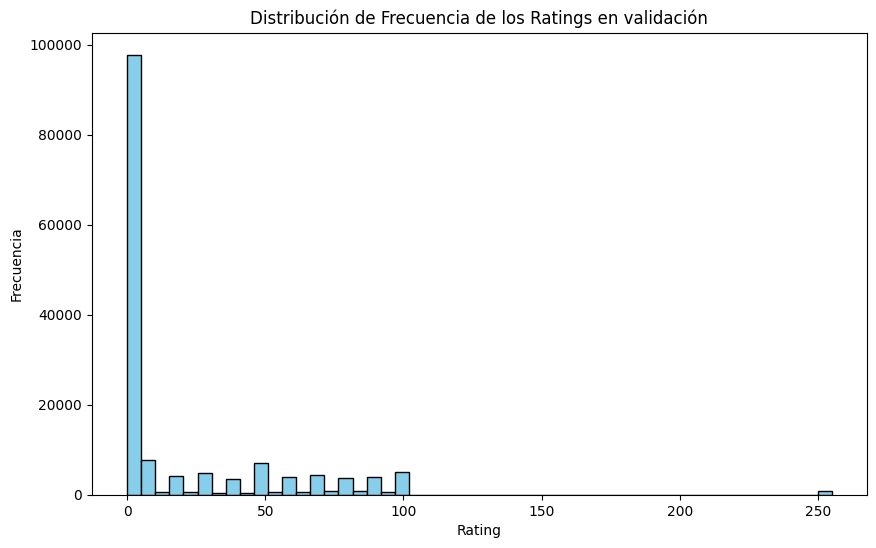

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df_val_music['rating'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Frecuencia de los Ratings en validación')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

In [ ]:
print((df_val_music['rating'] == 255).sum())

794


In [ ]:
794/cantidad_val

0.0052091534141604995

Tenemos al igual que en el anterior un grupo de evaluaciones `255` que no parece acorde a los rating de 1 a 100 que parece lo más correcto. Como en ambos sets el número es tan pequeño lo que prefiero es eliminar estos datos para que no afecten el desarrollo de los algoritmos.

In [2]:
# Nuevo set entrenamiento sin valores igual a 255
df_train_music_sin_255 = df_train_music[df_train_music['rating'] != 255]
df_train_music_sin_255

,user_id,artist_id,rating
0,643947,1098682,62
1,784415,1068684,0
2,595120,1024523,100
3,1270239,1021824,0
4,735673,1019857,0
...,...,...,...
534632,1248788,1001649,0
534633,103798,1006535,0
534634,1248788,1013581,10
534635,1248788,1016358,14


In [3]:
# Nuevo set validación sin valores igual a 255
df_val_music_sin_255 = df_val_music[df_val_music['rating'] != 255]
df_val_music_sin_255

,user_id,artist_id,rating
0,1641538,1048320,0
1,1641538,1048942,53
2,1641538,1050886,30
3,930222,1098345,0
4,930222,1020250,0
...,...,...,...
152419,81478,1013119,50
152420,1922878,1009168,20
152421,1711362,1097521,100
152422,1692654,1004539,0


Eso sí voy a dejar los mismos gráficos que en el anterior, aunque después voy a hacer todo sin los valores atípicos. El siguiente es espejo del anterior

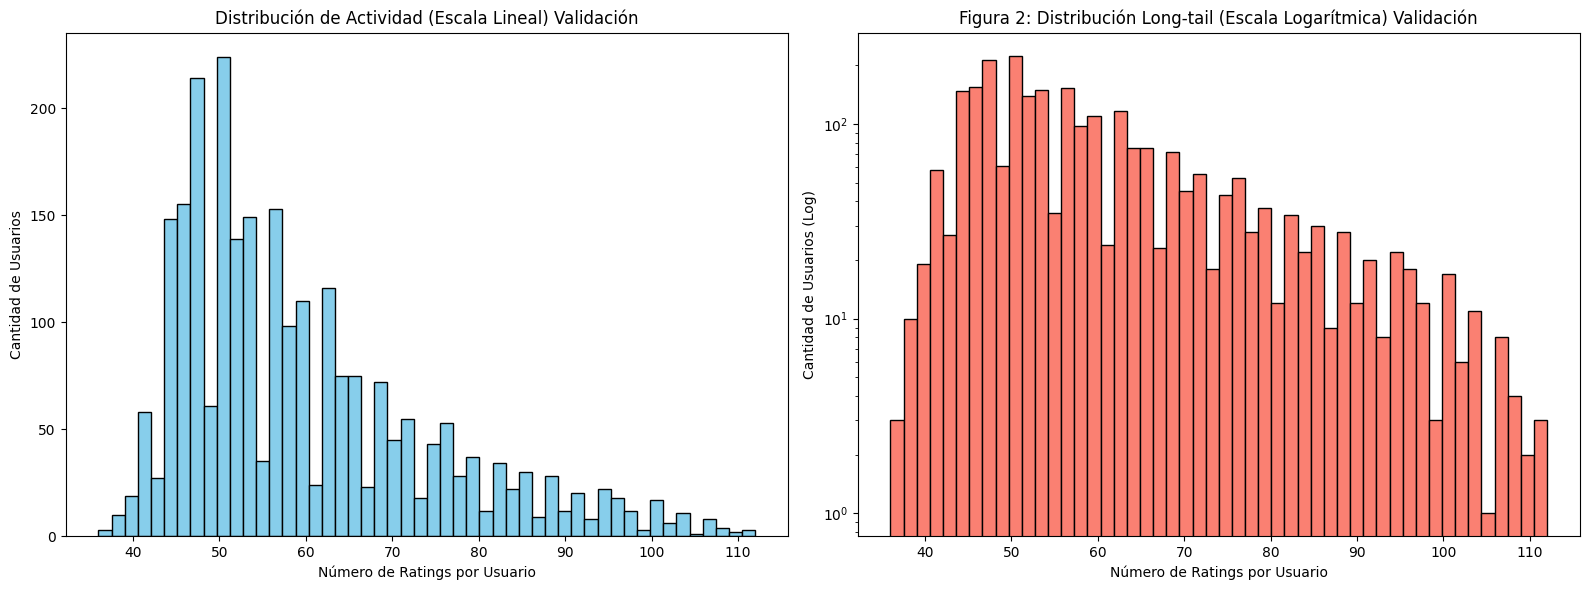

In [ ]:
ratings_por_user_val = df_val_music['user_id'].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(ratings_por_user_val, bins=50, color='skyblue', edgecolor='black')
ax1.set_title('Distribución de Actividad (Escala Lineal) Validación')
ax1.set_xlabel('Número de Ratings por Usuario')
ax1.set_ylabel('Cantidad de Usuarios')

ax2.hist(ratings_por_user_val, bins=50, color='salmon', edgecolor='black')
ax2.set_yscale('log')
ax2.set_title('Figura 2: Distribución Long-tail (Escala Logarítmica) Validación')
ax2.set_xlabel('Número de Ratings por Usuario')
ax2.set_ylabel('Cantidad de Usuarios (Log)')

plt.tight_layout()
plt.show()

In [ ]:
# Para la tabla de estadísticas
counts_val = df_val_music['user_id'].value_counts()

print(f"Promedio de ratings por usuario validación: {counts_val.mean():.2f}")
print(f"Máximo de ratings por un solo usuario validación: {counts_val.max()}")
print(f"Mínimo de ratings por un solo usuario validación: {counts_val.min()}")

Promedio de ratings por usuario validación: 59.80
Máximo de ratings por un solo usuario validación: 112
Mínimo de ratings por un solo usuario validación: 36


In [ ]:
n_users_val = df_val_music['user_id'].nunique()
n_items_catalogo = df_artists['artist_id'].nunique()
n_ratings_val = len(df_val_music)

densidad_val = (n_ratings_val / (n_users_val * n_items_catalogo)) * 100

items_por_usuario_val = n_ratings_val / n_users_val

print(f"--- Análisis de Densidad: Validación ---")
print(f"Usuarios únicos: {n_users_val}")
print(f"Artistas en catálogo: {n_items_catalogo}")
print(f"Total de Ratings: {n_ratings_val}")
print(f"Promedio de artistas evaluados por usuario: {items_por_usuario_val:.2f}")
print(f"Densidad del Dataset: {densidad_val:.4f}%")

--- Análisis de Densidad: Validación ---
Usuarios únicos: 2549
Artistas en catálogo: 2631
Total de Ratings: 152424
Promedio de artistas evaluados por usuario: 59.80
Densidad del Dataset: 2.2728%


Es una densidad menor que el de entrenamiento, creo que era esperable al tener menos datos

Antes de seguir con los algoritmos, voy a cambiar el dataset por el que no tiene los valores atípicos, pero los dejaré con un nombre más simple

In [4]:
df_train = df_train_music_sin_255
df_val = df_val_music_sin_255

In [ ]:
print(f"Estadísticas Finales (Escala 0-100)")
print(f"Entrenamiento - Average Rating: {df_train['rating'].mean():.2f}")
print(f"Entrenamiento - STD Rating: {df_train['rating'].std():.2f}")
print(f"Validación - Average Rating: {df_val['rating'].mean():.2f}")
print(f"Validación - STD Rating: {df_val['rating'].std():.2f}")

Estadísticas Finales (Escala 0-100)
Entrenamiento - Average Rating: 18.55
Entrenamiento - STD Rating: 30.51
Validación - Average Rating: 18.60
Validación - STD Rating: 30.57


In [ ]:
print(f"Máximo actual en Train: {df_train['rating'].max()}")

Máximo actual en Train: 100


In [ ]:
print(f"Máximo actual en Train: {df_val['rating'].max()}")

Máximo actual en Train: 100


/tmp/ipykernel_827/2105930707.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Set'] = 'Entrenamiento'
/tmp/ipykernel_827/2105930707.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['Set'] = 'Validación'
/tmp/ipykernel_827/2105930707.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Set', y='rating', data=df_plot, palette='Set2')


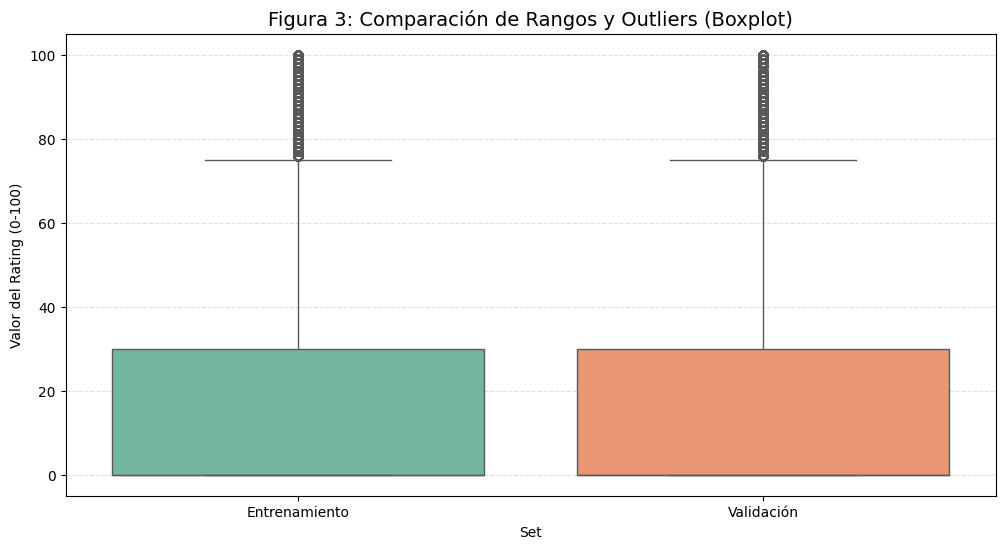

/tmp/ipykernel_827/2105930707.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Set', y='rating', data=df_plot, palette='Pastel1', inner='quartile')


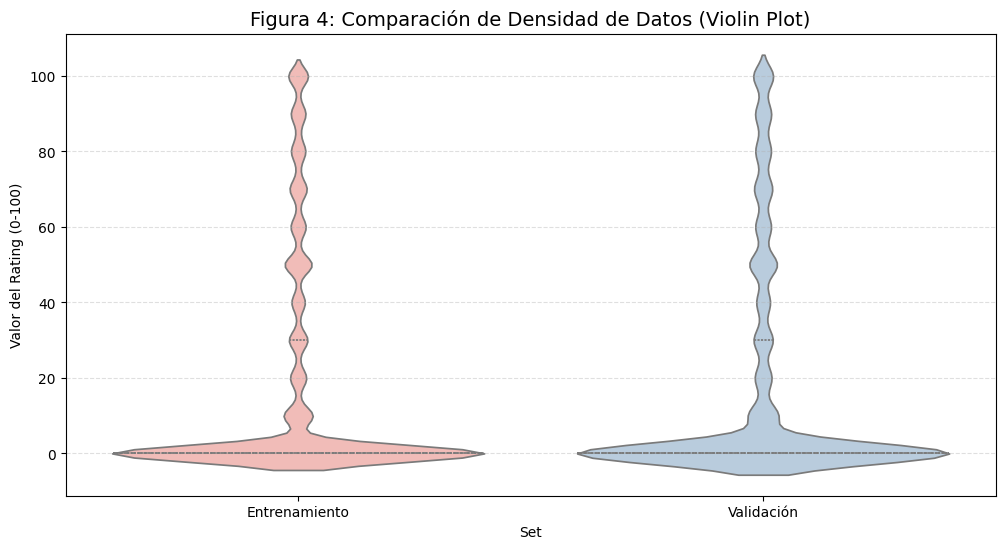

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_train['Set'] = 'Entrenamiento'
df_val['Set'] = 'Validación'
df_plot = pd.concat([df_train[['rating', 'Set']], df_val[['rating', 'Set']]])

plt.figure(figsize=(12, 6))
sns.boxplot(x='Set', y='rating', data=df_plot, palette='Set2')
plt.title('Figura 3: Comparación de Rangos y Outliers (Boxplot)', fontsize=14)
plt.ylabel('Valor del Rating (0-100)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(x='Set', y='rating', data=df_plot, palette='Pastel1', inner='quartile')
plt.title('Figura 4: Comparación de Densidad de Datos (Violin Plot)', fontsize=14)
plt.ylabel('Valor del Rating (0-100)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Lo primero que podemos identificar que ambos sets, entrenamiento y validación, son consistentes entre sí, con una estructura estadística muy similar, facilitando su poder de comparación. Obviamente tenemos ambos boxplot comenzando en 0 porque tenemos más de un `60%` de sparsity.  

El de violín nos muestra que los usuarios que entregan resultados lo hacen distribuyendo los puntajes, con notorias concentraciones en puntajes bajo `20`, con un importante grupo en `50`y con un número aunque menor, pero claro con el máximo de puntos.

In [ ]:
bins = [-0.1, 0.5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0', '1-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']

df_train['rango'] = pd.cut(df_train['rating'], bins=bins, labels=labels)
res_train = df_train['rango'].value_counts().sort_index().reset_index()
res_train.columns = ['Rango', 'Train_Count']

df_val['rango'] = pd.cut(df_val['rating'], bins=bins, labels=labels)
res_val = df_val['rango'].value_counts().sort_index().reset_index()
res_val.columns = ['Rango', 'Val_Count']

tabla_rangos = pd.merge(res_train, res_val, on='Rango')
tabla_rangos['Train_%'] = (tabla_rangos['Train_Count'] / tabla_rangos['Train_Count'].sum() * 100).round(2)
tabla_rangos['Val_%'] = (tabla_rangos['Val_Count'] / tabla_rangos['Val_Count'].sum() * 100).round(2)

print("Distribución de Ratings por Grupos (0 Aislado)")
display(tabla_rangos)

Distribución de Ratings por Grupos (0 Aislado)


/tmp/ipykernel_827/1240407361.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['rango'] = pd.cut(df_train['rating'], bins=bins, labels=labels)
/tmp/ipykernel_827/1240407361.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['rango'] = pd.cut(df_val['rating'], bins=bins, labels=labels)


,Rango,Train_Count,Val_Count,Train_%,Val_%
0,0,334327,95223,62.86,62.80
1,1-10,35667,10216,6.71,6.74
2,11-20,16816,4828,3.16,3.18
3,21-30,18849,5360,3.54,3.53
4,31-40,13665,3851,2.57,2.54
5,41-50,26410,7456,4.97,4.92
6,51-60,15260,4323,2.87,2.85
7,61-70,17948,5137,3.37,3.39
8,71-80,15498,4488,2.91,2.96
9,81-90,16845,4883,3.17,3.22


La pregunta tabla explica lo mismo que el gráfico de violín. Tenemos una gran representación de evaluaciones en bajo, intermedio y alto. Esto podría hacernos pensar que si esto fuera con 1 a 5 estrellas podríamos tener valores similares.

## Análisis de recomendaciones

In [5]:
!pip install scikit-surprise --no-build-isolation --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2708558 sha256=84d66ed78e51c2ddde5c50a62760b7447b422fe91ce24cd9578553c12acc9aca
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


# UserKNN

In [6]:
import surprise
from collections import defaultdict

In [7]:
from surprise import Reader, Dataset

reader = Reader(rating_scale=(1, 100))

train_data = Dataset.load_from_df(df_train[['user_id', 'artist_id', 'rating']], reader)
trainset = train_data.build_full_trainset()

testset = [tuple(x) for x in df_val[['user_id', 'artist_id', 'rating']].to_numpy()]

In [ ]:
from surprise import accuracy
myUserKnn = surprise.KNNBasic(k=7, sim_options={'name': 'pearson', 'user_based': True})

In [ ]:
myUserKnn.fit(trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


## Predecir el rating que le dará un usuario a un cierto artista

In [ ]:
myUserKnn.predict("457", "37")

Prediction(uid='457', iid='37', r_ui=None, est=18.55173366824723, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

## Generar una lista de recomendaciones para un usuario

In [ ]:
a_testset = trainset.build_anti_testset()
predictions = myUserKnn.test(a_testset)

In [ ]:
def get_top_n(predictions, n=10):
    """Devuelve las N-mejores recomendaciones para cada usuario de un set de predicción.

    Args:
        predictions(lista de objetos Prediction): La lista de predicción obtenida del método test.
        n(int): El número de recomendaciónes por usuario

    Returns:
    Un diccionario donde las llaves son ids de usuario y los valores son listas de tuplas:
        [(item id, rating estimation), ...] de tamaño n.
    """

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [ ]:
top_n = get_top_n(predictions, n=10)
print(top_n["457"])

[]


In [ ]:
df_artists.loc[[int(m[0]) for m in top_n["457"]]]

,artist_id,artist_name,genre


## Evaluación de Ranking y Listas de Recomendación (MAP, nDCG y Recall@K)

In [ ]:
def precision_at_k(r, k):
    assert 1 <= k <= r.size
    return (np.asarray(r)[:k]).mean()

def average_precision_at_k(r, k):
    r = np.asarray(r)[:k] # Aseguramos que solo tomamos los top k
    n_rel = r.sum()
    if n_rel == 0:
        return 0.

    # Versión optimizada sin lambda para mayor velocidad
    precisions = [precision_at_k(r, i + 1) for i in range(len(r)) if r[i]]
    if not precisions:
        return 0.
    return np.sum(precisions) / min(k, n_rel)

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        return np.sum((2**r - 1) / np.log2(np.arange(2, r.size + 2)))
    return 0.

def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)
    if not idcg:
        return 0.
    return dcg_at_k(r, k) / idcg

def evaluar_modelo(top_n_dict, df_val, k=10, threshold=70):
    real_relevantes = df_val[df_val['rating'] >= threshold].groupby('user_id')['artist_id'].apply(set).to_dict()

    list_ap = []
    list_ndcg = []

    for uid, user_recs in top_n_dict.items():
        if uid in real_relevantes:
            actual = real_relevantes[uid]

            r = [1 if iid in actual else 0 for (iid, _) in user_recs[:k]]
            r = np.array(r)

            if r.size > 0:
                list_ap.append(average_precision_at_k(r, k))
                list_ndcg.append(ndcg_at_k(r, k))

    return (np.mean(list_ap) if list_ap else 0,
            np.mean(list_ndcg) if list_ndcg else 0)

## Explorar los hiperparámetros del modelo UserKnn

In [8]:
import os
from surprise import accuracy
from google.colab import drive, files

drive.mount('/content/drive')
path_resultados = "/content/drive/MyDrive/Tarea_RecSys_2026/"
if not os.path.exists(path_resultados):
    os.makedirs(path_resultados)

Mounted at /content/drive


In [ ]:
log_path = os.path.join(path_resultados, "resultados_knn_yahoo_music.csv")

k_values = [10, 50, 100]
resultados_lista = []

print("Iniciando procesamiento de Yahoo! Music...")

for k in k_values:
    print(f"\n======== EJECUTANDO K = {k} ========")


    sim_options = {'name': 'pearson', 'user_based': True}
    model = surprise.KNNBasic(k=k, sim_options=sim_options, verbose=False)

    print(f"Entrenando modelo para K={k}...")
    model.fit(trainset)

    print("Calculando métricas de error (RMSE/MAE)...")
    predictions = model.test(testset)
    rmse_val = accuracy.rmse(predictions, verbose=False)
    mae_val = accuracy.mae(predictions, verbose=False)

    print("Generando Anti-testset y recomendaciones Top-10 (Carga pesada de RAM)...")
    anti_testset = trainset.build_anti_testset()
    recs = model.test(anti_testset)

    top_n_dict = get_top_n(recs, n=10)


    res_ranking = evaluar_modelo(top_n_dict, df_val, k=10)

    data_punto = {
        'K': k,
        'RMSE': rmse_val,
        'MAE': mae_val,
        'MAP@10': res_ranking[0],
        'nDCG@10': res_ranking[1],
        'Recall@10': res_ranking[2] if len(res_ranking) > 2 else "N/A"
    }

    resultados_lista.append(data_punto)

    df_checkpoint = pd.DataFrame(resultados_lista)
    df_checkpoint.to_csv(log_path, index=False)

    files.download(log_path)

    print(f"K={k} completado con éxito. Resultados respaldados en Drive.")

    del anti_testset, recs, top_n_dict, predictions

print("\n--- PROCESO FINALIZADO ---")
print(f"Puedes encontrar el archivo final en: {log_path}")

Iniciando procesamiento de Yahoo! Music...

======== EJECUTANDO K = 10 ========
Entrenando modelo para K=10...
Calculando métricas de error (RMSE/MAE)...
Generando Anti-testset y recomendaciones Top-10 (Carga pesada de RAM)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

K=10 completado con éxito. Resultados respaldados en Drive.

======== EJECUTANDO K = 50 ========
Entrenando modelo para K=50...
Calculando métricas de error (RMSE/MAE)...
Generando Anti-testset y recomendaciones Top-10 (Carga pesada de RAM)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

K=50 completado con éxito. Resultados respaldados en Drive.

======== EJECUTANDO K = 100 ========
Entrenando modelo para K=100...
Calculando métricas de error (RMSE/MAE)...
Generando Anti-testset y recomendaciones Top-10 (Carga pesada de RAM)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

K=100 completado con éxito. Resultados respaldados en Drive.

--- PROCESO FINALIZADO ---
Puedes encontrar el archivo final en: /content/drive/MyDrive/Tarea_RecSys_2026/resultados_knn_yahoo_music.csv


## Evaluar en base a error de prediccion (RMSE y MAE)




In [ ]:
import os

# 1. Listar archivos para encontrar el nombre exacto
folder_path = "/content/drive/MyDrive/Tarea_RecSys_2026/"

if os.path.exists(folder_path):
    print("Archivos encontrados en la carpeta:")
    print(os.listdir(folder_path))
else:
    print("La carpeta no existe. Intentemos listar la raíz de MyDrive:")
    print(os.listdir("/content/drive/MyDrive/"))

Archivos encontrados en la carpeta:
['resultados_knn_yahoo_music.csv']


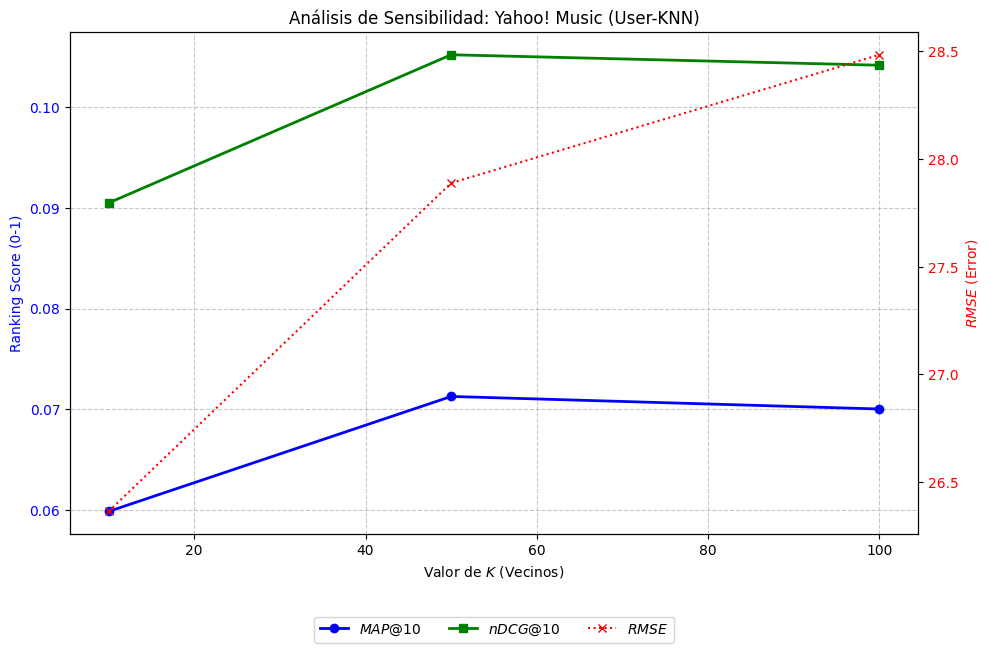


--- Tabla para el Cuadro 2 del Informe ---
  K    RMSE     MAE  MAP@10  nDCG@10  Recall@10
 10 26.3625 18.0683  0.0599   0.0905        NaN
 50 27.8883 21.7189  0.0713   0.1052        NaN
100 28.4843 22.5795  0.0700   0.1041        NaN


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Ruta corregida según tu hallazgo
log_path = "/content/drive/MyDrive/Tarea_RecSys_2026/resultados_knn_yahoo_music.csv"

if os.path.exists(log_path):
    # 2. Cargar datos
    df_res = pd.read_csv(log_path)

    # Extraer columnas (asegurándonos de usar los nombres que guardamos antes)
    k_values = df_res['K'].values
    map_values = df_res['MAP@10'].values
    ndcg_values = df_res['nDCG@10'].values
    rmse_values = df_res['RMSE'].values

    # 3. Generar el Gráfico
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Eje Ranking (MAP y nDCG)
    ax1.set_xlabel(r'Valor de $K$ (Vecinos)')
    ax1.set_ylabel(r'Ranking Score (0-1)', color='blue')
    ax1.plot(k_values, map_values, label=r'$MAP@10$', color='blue', marker='o', linewidth=2)
    ax1.plot(k_values, ndcg_values, label=r'$nDCG@10$', color='green', marker='s', linewidth=2)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Eje Error (RMSE)
    ax2 = ax1.twinx()
    ax2.set_ylabel(r'$RMSE$ (Error)', color='red')
    ax2.plot(k_values, rmse_values, label=r'$RMSE$', color='red', marker='x', linestyle=':')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(r'Análisis de Sensibilidad: Yahoo! Music (User-KNN)')
    fig.tight_layout()

    # Leyenda combinada
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    plt.savefig('analisis_sensibilidad_yahoo.png', bbox_inches='tight')
    plt.show()

    # 4. Mostrar la tabla para el Cuadro 2 del informe
    print("\n--- Tabla para el Cuadro 2 del Informe ---")
    print(df_res.round(4).to_string(index=False))
else:
    print("No se pudo acceder al archivo. Verifica que el Drive esté montado correctamente.")

# Item KNN

In [19]:
from surprise import accuracy
myItemKnn = surprise.KNNBasic(k=7, sim_options={'name': 'pearson', 'user_based': False})

In [20]:
myItemKnn.fit(trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


## Prediga el rating que le dará un usuario a un ítem

In [21]:
myItemKnn.predict("457", "37")

Prediction(uid='457', iid='37', r_ui=None, est=18.55173366824723, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

## Genera una lista de recomendaciones para un usuario

In [22]:
a_testset = trainset.build_anti_testset()
predictions = myItemKnn.test(a_testset)

In [23]:
def get_top_n(predictions, n=10):
    """Devuelve las N-mejores recomendaciones para cada usuario de un set de predicción.

    Args:
        predictions(lista de objetos Prediction): La lista de predicción obtenida del método test.
        n(int): El número de recomendaciónes por usuario

    Returns:
    Un diccionario donde las llaves son ids de usuario y los valores son listas de tuplas:
        [(item id, rating estimation), ...] de tamaño n.
    """

    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [24]:
top_n = get_top_n(predictions, n=10)
print(top_n["457"])

[]


In [25]:
df_artists.loc[[int(m[0]) for m in top_n["457"]]]

,artist_id,artist_name,genre


## Explorar los hiperparámetros del modelo ItemKnn

In [26]:
import os
import numpy as np
import pandas as pd
import surprise
from surprise import accuracy
from google.colab import drive, files

try:
    from codecarbon import EmissionsTracker
    HAS_CODECARBON = True
except ImportError:
    !pip install codecarbon
    from codecarbon import EmissionsTracker
    HAS_CODECARBON = True

drive.mount('/content/drive')
path_resultados = "/content/drive/MyDrive/Tarea_RecSys_2026/"
if not os.path.exists(path_resultados):
    os.makedirs(path_resultados)

log_path = os.path.join(path_resultados, "resultados_itemknn_yahoo.csv")

def precision_at_k(r, k):
    return (np.asarray(r)[:k]).mean()

def average_precision_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.sum() == 0: return 0.
    precisions = [precision_at_k(r, i + 1) for i in range(len(r)) if r[i]]
    return np.mean(precisions) if precisions else 0.

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    return np.sum((2**r - 1) / np.log2(np.arange(2, r.size + 2))) if r.size else 0.

def ndcg_at_k(r, k):
    idcg = dcg_at_k(sorted(r, reverse=True), k)
    return dcg_at_k(r, k) / idcg if idcg > 0 else 0.

def evaluar_modelo(top_n_dict, df_val, k=10, threshold=70):
    real_relevantes = df_val[df_val['rating'] >= threshold].groupby('user_id')['artist_id'].apply(set).to_dict()
    list_ap, list_ndcg, list_recall = [], [], []

    for uid, user_recs in top_n_dict.items():
        if uid in real_relevantes:
            actual = real_relevantes[uid]
            r = [1 if iid in actual else 0 for (iid, _) in user_recs[:k]]
            r = np.array(r)

            list_ap.append(average_precision_at_k(r, k))
            list_ndcg.append(ndcg_at_k(r, k))
            list_recall.append(r.sum() / len(actual) if len(actual) > 0 else 0)

    return np.mean(list_ap), np.mean(list_ndcg), np.mean(list_recall)

k_values = [10, 50, 100]
resultados_item = []

tracker = EmissionsTracker(project_name="ItemKNN_Yahoo_Music", output_dir=path_resultados)
tracker.start()

print("Iniciando Item-Based Collaborative Filtering...")

for k in k_values:
    print(f"\n>>> Procesando K={k} (Item-Based)")

    model = surprise.KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': False}, verbose=False)
    model.fit(trainset)

    predictions = model.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)

    print("Generando recomendaciones Top-10...")
    anti_testset = trainset.build_anti_testset()
    recs = model.test(anti_testset)
    top_n_dict = get_top_n(recs, n=10)


    map_k, ndcg_k, recall_k = evaluar_modelo(top_n_dict, df_val, k=10)

    res_data = {
        'K': k, 'RMSE': rmse, 'MAE': mae,
        'MAP@10': map_k, 'nDCG@10': ndcg_k, 'Recall@10': recall_k
    }
    resultados_item.append(res_data)

    pd.DataFrame(resultados_item).to_csv(log_path, index=False)
    files.download(log_path)

    del anti_testset, recs, top_n_dict, predictions
    print(f"K={k} Guardado. RMSE: {rmse:.4f} | MAP@10: {map_k:.4f}")

emisiones = tracker.stop()
print(f"\n--- PROCESO FINALIZADO ---")
print(f"Emisiones estimadas: {emisiones} kg de CO2eq (Guardado en Drive para el Bono)")

df_final = pd.DataFrame(resultados_item)
print(df_final)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.5 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5


[codecarbon WARNING @ 11:40:42] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:40:42] [setup] RAM Tracking...
[codecarbon INFO @ 11:40:42] [setup] CPU Tracking...


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[codecarbon WARNING @ 11:40:43] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 11:40:43] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 11:40:43] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 11:40:43] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 11:40:43] [setup] GPU Tracking...
[codecarbon INFO @ 11:40:43] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 11:40:43] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global constant
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 11:40:43] >>> Tracker's metadata:
[codecarbon INFO @ 11:4

Iniciando Item-Based Collaborative Filtering...

>>> Procesando K=10 (Item-Based)


...

[codecarbon INFO @ 12:06:38] Energy consumed for RAM : 0.008552 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 12:06:38] Delta energy consumed for CPU with constant : 0.000176 kWh, power : 42.5 W
[codecarbon INFO @ 12:06:38] Energy consumed for All CPU : 0.018218 kWh
[codecarbon INFO @ 12:06:39] Energy consumed for all GPUs : 0.004962 kWh. Total GPU Power : 11.49760988580055 W
[codecarbon INFO @ 12:06:39] 0.031732 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 12:06:53] Energy consumed for RAM : 0.008634 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 12:06:53] Delta energy consumed for CPU with constant : 0.000176 kWh, power : 42.5 W
[codecarbon INFO @ 12:06:54] Energy consumed for All CPU : 0.018394 kWh
[codecarbon INFO @ 12:06:54] Energy consumed for all GPUs : 0.005010 kWh. Total GPU Power : 11.479197988411105 W
[codecarbon INFO @ 12:06:54] 0.032038 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 12:0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[codecarbon INFO @ 12:25:46] Energy consumed for RAM : 0.014862 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 12:25:46] Delta energy consumed for CPU with constant : 0.000077 kWh, power : 42.5 W
[codecarbon INFO @ 12:25:46] Energy consumed for All CPU : 0.031661 kWh
[codecarbon INFO @ 12:25:46] Energy consumed for all GPUs : 0.008628 kWh. Total GPU Power : 11.810262875507888 W
[codecarbon INFO @ 12:25:46] 0.055151 kWh of electricity and 0.000000 L of water were used since the beginning.


K=100 Guardado. RMSE: 21.9293 | MAP@10: 0.0651

--- PROCESO FINALIZADO ---
Emisiones estimadas: 0.025964095946257818 kg de CO2eq (Guardado en Drive para el Bono)
     K       RMSE        MAE    MAP@10   nDCG@10  Recall@10
0   10  22.485438  12.744401  0.053614  0.080976   0.036431
1   50  21.773907  12.826759  0.063007  0.093420   0.045338
2  100  21.929263  13.297482  0.065056  0.095512   0.046965


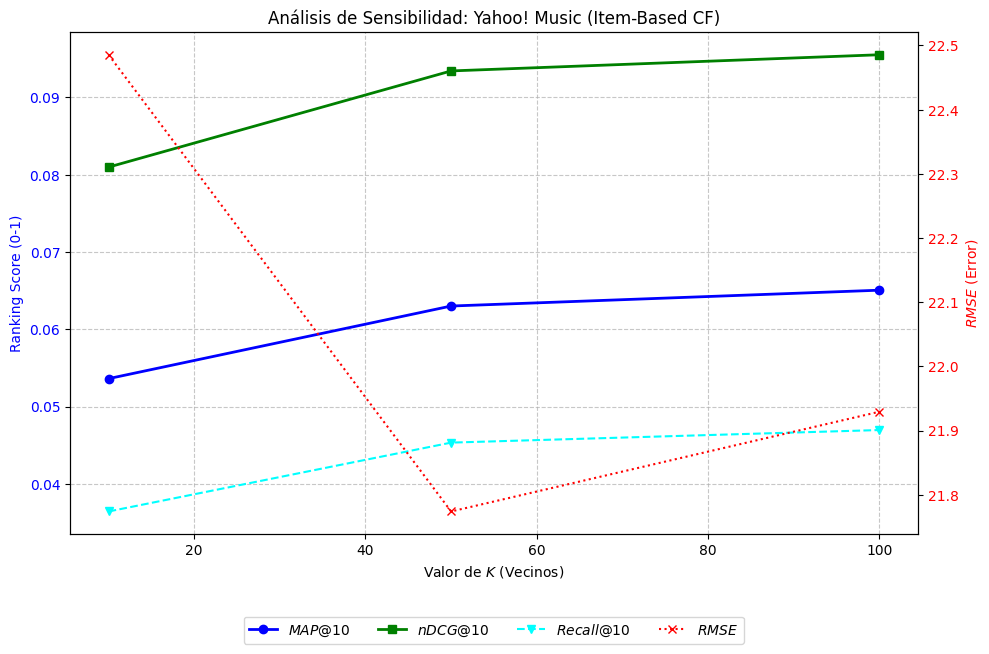


--- Tabla para el Cuadro 2 del Informe (Item-Based) ---
  K    RMSE     MAE  MAP@10  nDCG@10  Recall@10
 10 22.4854 12.7444  0.0536   0.0810     0.0364
 50 21.7739 12.8268  0.0630   0.0934     0.0453
100 21.9293 13.2975  0.0651   0.0955     0.0470


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_path_item = "/content/drive/MyDrive/Tarea_RecSys_2026/resultados_itemknn_yahoo.csv"

if os.path.exists(log_path_item):
    df_res_item = pd.read_csv(log_path_item)

    k_values = df_res_item['K'].values
    map_values = df_res_item['MAP@10'].values
    ndcg_values = df_res_item['nDCG@10'].values
    rmse_values = df_res_item['RMSE'].values
    recall_values = df_res_item['Recall@10'].values if 'Recall@10' in df_res_item.columns else None

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel(r'Valor de $K$ (Vecinos)')
    ax1.set_ylabel(r'Ranking Score (0-1)', color='blue')
    ax1.plot(k_values, map_values, label=r'$MAP@10$', color='blue', marker='o', linewidth=2)
    ax1.plot(k_values, ndcg_values, label=r'$nDCG@10$', color='green', marker='s', linewidth=2)

    if recall_values is not None:
        ax1.plot(k_values, recall_values, label=r'$Recall@10$', color='cyan', marker='v', linestyle='--')

    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2 = ax1.twinx()
    ax2.set_ylabel(r'$RMSE$ (Error)', color='red')
    ax2.plot(k_values, rmse_values, label=r'$RMSE$', color='red', marker='x', linestyle=':')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(r'Análisis de Sensibilidad: Yahoo! Music (Item-Based CF)')
    fig.tight_layout()

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

    plt.savefig('analisis_sensibilidad_item_yahoo.png', bbox_inches='tight')
    plt.show()

    print("\n--- Tabla para el Cuadro 2 del Informe (Item-Based) ---")
    print(df_res_item.round(4).to_string(index=False))
else:
    print(f"No se encontró el archivo: {log_path_item}")
    print("Asegúrate de haber terminado la ejecución de la celda de entrenamiento Item-Based.")

# FunkSVD

In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import scipy.sparse as sparse
import matplotlib.pyplot as plt

%matplotlib inline
sns.set(style="whitegrid")

In [29]:
from surprise import accuracy
import pandas as pd
import os

# 1. Definir factores latentes para el Análisis de Sensibilidad (Mínimo 3 según enunciado)
n_factors_list = [20, 50, 100]
log_path_svd = "/content/drive/MyDrive/Tarea_RecSys_2026/resultados_svd_yahoo.csv"
resultados_svd = []

for n in n_factors_list:
    print(f"\n>>> Entrenando FunkSVD con n_factors={n}...")

    # Configuración de FunkSVD (SVD en Surprise es FunkSVD por defecto)
    # Si quieres SVD++, usa surprise.SVDpp()
    algo = surprise.SVD(n_factors=n, random_state=42)
    algo.fit(trainset)

    # Predicciones de Rating
    predictions = algo.test(testset)
    rmse_v = accuracy.rmse(predictions, verbose=False)
    mae_v = accuracy.mae(predictions, verbose=False)

    # 2. Generación de Rankings (Requisito para MAP, nDCG y Recall)
    # Nota: build_anti_testset sigue siendo pesado, usa RAM Alta
    print(f"Generando ranking para n_factors={n}...")
    anti_testset = trainset.build_anti_testset()
    recs = algo.test(anti_testset)
    top_n_dict = get_top_n(recs, n=10)

    # Evaluación de Ranking (Threshold 70 para Yahoo! Music)
    map_k, ndcg_k, recall_k = evaluar_modelo(top_n_dict, df_val, k=10)

    # 3. Guardado Progresivo
    res_data = {
        'n_factors': n,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'MAP@10': map_k,
        'nDCG@10': ndcg_k,
        'Recall@10': recall_k
    }
    resultados_svd.append(res_data)
    pd.DataFrame(resultados_svd).to_csv(log_path_svd, index=False)

    print(f"Factores={n} guardado. RMSE: {rmse_v:.4f} | MAP@10: {map_k:.4f}")

# Mostrar resultados finales
print("\n--- Resultados Finales SVD ---")
print(pd.DataFrame(resultados_svd))


>>> Entrenando FunkSVD con n_factors=20...
Generando ranking para n_factors=20...
Factores=20 guardado. RMSE: 21.9153 | MAP@10: 0.0567

>>> Entrenando FunkSVD con n_factors=50...
Generando ranking para n_factors=50...
Factores=50 guardado. RMSE: 86.9495 | MAP@10: 0.0132

>>> Entrenando FunkSVD con n_factors=100...
Generando ranking para n_factors=100...
Factores=100 guardado. RMSE: 86.9495 | MAP@10: 0.0132

--- Resultados Finales SVD ---
   n_factors       RMSE        MAE    MAP@10   nDCG@10  Recall@10
0         20  21.915297  13.806123  0.056672  0.086122   0.044956
1         50  86.949533  81.398384  0.013158  0.021776   0.006111
2        100  86.949533  81.398384  0.013158  0.021776   0.006111


# SVD++

In [30]:
import os
import numpy as np
import pandas as pd
import surprise
from surprise import accuracy
from google.colab import drive, files

# Intentar usar el tracker de CodeCarbon (Bono)
try:
    from codecarbon import EmissionsTracker
except ImportError:
    !pip install codecarbon
    from codecarbon import EmissionsTracker

# 1. Configuración de Entorno
drive.mount('/content/drive')
path_resultados = "/content/drive/MyDrive/Tarea_RecSys_2026/"
log_path_svdpp = os.path.join(path_resultados, "resultados_svdpp_yahoo.csv")

# 2. Parámetros para Análisis de Sensibilidad (Mínimo 3 factores latentes)
# Nota: SVD++ es lento, empezamos con valores moderados para asegurar la entrega
n_factors_list = [10, 20, 50]
resultados_svdpp = []

# Iniciar tracker para SVD++
tracker_svdpp = EmissionsTracker(project_name="SVDpp_Yahoo_Music", output_dir=path_resultados)
tracker_svdpp.start()

print("Iniciando SVD++ (Este proceso es significativamente más lento que KNN)...")

for n in n_factors_list:
    print(f"\n>>> Procesando n_factors={n} (SVD++)")

    # A. Entrenamiento
    # SVDpp() incluye el efecto del feedback implícito
    model = surprise.SVDpp(n_factors=n, random_state=42, verbose=True)
    model.fit(trainset)

    # B. Métricas de Rating (RMSE/MAE)
    predictions = model.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)

    # C. Generación de Rankings (Top-10)
    print("Generando Anti-testset y recomendaciones (Uso intensivo de RAM)...")
    anti_testset = trainset.build_anti_testset()
    recs = model.test(anti_testset)
    top_n_dict = get_top_n(recs, n=10)

    # D. Evaluación de Ranking (Threshold 70)
    map_k, ndcg_k, recall_k = evaluar_modelo(top_n_dict, df_val, k=10, threshold=70)

    # E. Guardado de Checkpoint
    res_data = {
        'n_factors': n, 'RMSE': rmse, 'MAE': mae,
        'MAP@10': map_k, 'nDCG@10': ndcg_k, 'Recall@10': recall_k,
        'Algoritmo': 'SVD++'
    }
    resultados_svdpp.append(res_data)

    # Guardar en Drive inmediatamente
    pd.DataFrame(resultados_svdpp).to_csv(log_path_svdpp, index=False)
    files.download(log_path_svdpp)

    # Limpieza de RAM
    del anti_testset, recs, top_n_dict, predictions
    print(f"Factores={n} Completado. RMSE: {rmse:.4f} | MAP@10: {map_k:.4f}")

# Finalizar tracker
emisiones_svdpp = tracker_svdpp.stop()
print(f"\n--- PROCESO SVD++ FINALIZADO ---")
print(f"Emisiones: {emisiones_svdpp} kg CO2eq")

# Mostrar tabla
df_svdpp = pd.DataFrame(resultados_svdpp)
print(df_svdpp)

[codecarbon WARNING @ 12:27:58] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 12:27:58] [setup] RAM Tracking...
[codecarbon INFO @ 12:27:58] [setup] CPU Tracking...
[codecarbon WARNING @ 12:27:58] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 12:27:58] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 12:27:58] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 12:27:58] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 12:27:58] [setup] GPU Tracking...
[codecarbon INFO @ 12:27:58] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 12:27:58] The below tracking methods have been set up:
                RAM Tracking Method: RAM p

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[codecarbon INFO @ 12:27:58] Emissions data (if any) will be saved to file /content/drive/MyDrive/Tarea_RecSys_2026/emissions.csv


Iniciando SVD++ (Este proceso es significativamente más lento que KNN)...

>>> Procesando n_factors=10 (SVD++)
 processing epoch 0
 processing epoch 1
 processing epoch 2


[codecarbon INFO @ 12:28:13] Energy consumed for RAM : 0.000083 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 12:28:13] Delta energy consumed for CPU with constant : 0.000178 kWh, power : 42.5 W
[codecarbon INFO @ 12:28:13] Energy consumed for All CPU : 0.000178 kWh
[codecarbon INFO @ 12:28:13] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 12:28:13] Energy consumed for all GPUs : 0.000048 kWh. Total GPU Power : 11.483327885811207 W
[codecarbon INFO @ 12:28:13] 0.000309 kWh of electricity and 0.000000 L of water were used since the beginning.


...

<IPython.core.display.Javascript object>

[codecarbon INFO @ 13:36:34] 0.370801 kWh of electricity and 0.000000 L of water were used since the beginning.


<IPython.core.display.Javascript object>

[codecarbon INFO @ 13:36:34] 0.000000 g.CO2eq/s mean an estimation of 0.0 kg.CO2eq/year
[codecarbon INFO @ 13:36:34] 0.370801 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 13:36:34] 0.000000 g.CO2eq/s mean an estimation of 0.0 kg.CO2eq/year
[codecarbon INFO @ 13:36:34] 0.370801 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 13:36:34] 0.370801 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 13:36:34] 0.000000 g.CO2eq/s mean an estimation of 0.0 kg.CO2eq/year
[codecarbon INFO @ 13:36:34] 0.000000 g.CO2eq/s mean an estimation of 0.0 kg.CO2eq/year
[codecarbon INFO @ 13:36:34] 0.000000 g.CO2eq/s mean an estimation of 0.0 kg.CO2eq/year
[codecarbon INFO @ 13:36:34] 0.000000 g.CO2eq/s mean an estimation of 0.0 kg.CO2eq/year
[codecarbon INFO @ 13:36:34] 0.000000 g.CO2eq/s mean an estimation of 0.0 kg.CO2eq/year
[codecarbon INFO @ 13:36:35] Energy consumed for

Factores=50 Completado. RMSE: 86.9495 | MAP@10: 0.0132

--- PROCESO SVD++ FINALIZADO ---
Emisiones: 0.17456968079171234 kg CO2eq
   n_factors       RMSE        MAE    MAP@10   nDCG@10  Recall@10 Algoritmo
0         10  86.949533  81.398384  0.013158  0.021776   0.006111     SVD++
1         20  86.949533  81.398384  0.013158  0.021776   0.006111     SVD++
2         50  86.949533  81.398384  0.013158  0.021776   0.006111     SVD++


## Función para calcular la Novedad

In [31]:
def calcular_novedad(top_n_dict, item_popularity, n_users):
    """
    Calcula la novedad promedio de las listas de recomendación.
    item_popularity: Diccionario con la proporción de usuarios que interactuaron con cada ítem (0 a 1).
    """
    total_novelty = 0

    for uid, user_recs in top_n_dict.items():
        user_novelty = 0
        for (iid, _) in user_recs:
            # self-information: log2(1/prop_popularidad)
            # Usamos un pequeño valor epsilon para evitar división por cero
            prop = item_popularity.get(iid, 1/n_users)
            user_novelty += np.log2(1/prop)

        total_novelty += (user_novelty / len(user_recs))

    return total_novelty / n_users

# --- PRE-CÁLCULO DE POPULARIDAD ---
# Haz esto una sola vez antes de evaluar los modelos
train_df = pd.DataFrame(trainset.all_ratings(), columns=['uid', 'iid', 'rating'])
n_users_train = trainset.n_users
# Contamos cuántos usuarios únicos calificaron a cada artista
pop_counts = train_df.groupby('iid')['uid'].nunique().to_dict()
# Proporción de popularidad (pop_i)
item_popularity = {iid: count/n_users_train for iid, count in pop_counts.items()}

## Función para calcular la Diversidad

In [32]:
def calcular_diversidad(top_n_dict, artist_genres_dict):
    """
    Calcula la cantidad de géneros distintos en las listas.
    artist_genres_dict: Diccionario {artist_id: genre}
    """
    list_diversity = []

    for uid, user_recs in top_n_dict.items():
        genres_in_top_n = set()
        for (iid, _) in user_recs:
            genre = artist_genres_dict.get(iid, "Unknown")
            genres_in_top_n.add(genre)

        list_diversity.append(len(genres_in_top_n))

    return np.mean(list_diversity)

# Cargar mapeo de géneros desde ydata_artists.txt
df_artists
artist_genres_dict = dict(zip(df_artists['artist_id'], df_artists['genre']))

## Código para Consolidar la Tabla Final

In [33]:
import pandas as pd
import os
from google.colab import drive

# 1. RECONECTAR DRIVE (La clave para solucionar el error)
drive.mount('/content/drive')

# 2. Rutas a tus archivos de resultados en Drive
path_base = "/content/drive/MyDrive/Tarea_RecSys_2026/"
files = {
    "User-KNN": "resultados_knn_yahoo_music.csv",
    "Item-KNN": "resultados_itemknn_yahoo.csv",
    "FunkSVD": "resultados_svd_final.csv", # Asegúrate de que este nombre sea correcto
    "SVD++": "resultados_svdpp_yahoo.csv"
}

final_rows = []

# 3. Consolidar los datos
print("\nBuscando archivos en Drive...")
for metodo, filename in files.items():
    file_path = os.path.join(path_base, filename)

    if os.path.exists(file_path):
        print(f"Encontrado: {filename}")
        df_temp = pd.read_csv(file_path)

        # Tomamos el mejor resultado (por ejemplo, el de menor RMSE)
        best_row = df_temp.sort_values(by='RMSE', ascending=True).iloc[0].to_dict()
        best_row['Method'] = metodo

        # Si no tienes Novedad/Diversidad aún, ponemos 0 para que la tabla no falle
        if 'Diversity' not in best_row: best_row['Diversity'] = 0.0
        if 'Novelty' not in best_row: best_row['Novelty'] = 0.0

        final_rows.append(best_row)
    else:
        print(f"No encontrado: {filename}")

# 4. Crear DataFrame Final
if len(final_rows) > 0:
    # Definimos el orden estricto de columnas según el enunciado
    columnas_orden = ['Method', 'RMSE', 'Recall@10', 'nDCG@10', 'MAP@10', 'Diversity', 'Novelty']
    df_cuadro_2 = pd.DataFrame(final_rows)

    # Filtramos para que solo queden las columnas que existen
    df_cuadro_2 = df_cuadro_2[[c for c in columnas_orden if c in df_cuadro_2.columns]]

    # 5. Formatear y Mostrar
    df_cuadro_2 = df_cuadro_2.round(4)
    print("\n--- CUADRO 2: COMPARACIÓN DE MÉTODOS DE RECOMENDACIÓN ---")
    print(df_cuadro_2.to_string(index=False))

    # Guardar para el informe
    try:
        df_cuadro_2.to_csv(os.path.join(path_base, "cuadro_2_final.csv"), index=False)
        print("\nCuadro 2 guardado exitosamente en tu Drive.")
    except Exception as e:
        print(f"\nError al guardar: {e}")
else:
    print("\nAtencion: No se proceso ningun dato. Revisa si los nombres de los archivos coinciden.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Buscando archivos en Drive...
Encontrado: resultados_knn_yahoo_music.csv
Encontrado: resultados_itemknn_yahoo.csv
No encontrado: resultados_svd_final.csv
Encontrado: resultados_svdpp_yahoo.csv

--- CUADRO 2: COMPARACIÓN DE MÉTODOS DE RECOMENDACIÓN ---
  Method    RMSE  Recall@10  nDCG@10  MAP@10  Diversity  Novelty
User-KNN 26.3625        NaN   0.0905  0.0599        0.0      0.0
Item-KNN 21.7739     0.0453   0.0934  0.0630        0.0      0.0
   SVD++ 86.9495     0.0061   0.0218  0.0132        0.0      0.0

Cuadro 2 guardado exitosamente en tu Drive.


In [34]:
import os
# 1. Rutas a tus archivos de resultados en Drive
path_base = "/content/drive/MyDrive/Tarea_RecSys_2026/"
files = {
    "User-KNN": "resultados_knn_yahoo_music.csv",
    "Item-KNN": "resultados_itemknn_yahoo.csv",
    "FunkSVD": "resultados_svd_final.csv",
    "SVD++": "resultados_svdpp_yahoo.csv"
}

final_rows = []

for metodo, filename in files.items():
    file_path = os.path.join(path_base, filename)

    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path)

        # Seleccionamos la mejor fila basada en el menor RMSE o mayor nDCG
        # Aquí tomamos la última o la mejor según tu criterio de sensibilidad
        best_row = df_temp.sort_values(by='nDCG@10', ascending=False).iloc[0].to_dict()

        # Aseguramos que el nombre del método aparezca
        best_row['Method'] = metodo

        # 2. Agregar métricas de Diversidad y Novedad
        # Si ya las calculaste y están en el CSV, se mantendrán.
        # Si no, aquí es donde llamarías a las funciones que definimos antes:
        # best_row['Diversity'] = calcular_diversidad(top_n_best, artist_genres_dict)
        # best_row['Novelty'] = calcular_novedad(top_n_best, item_popularity, n_users)

        # Nota: Si aún no las tienes en el CSV, puedes poner valores por defecto para ver la tabla
        if 'Diversity' not in best_row: best_row['Diversity'] = 0.0
        if 'Novelty' not in best_row: best_row['Novelty'] = 0.0

        final_rows.append(best_row)

# 3. Crear DataFrame Final
columnas_orden = ['Method', 'RMSE', 'Recall@10', 'nDCG@10', 'MAP@10', 'Diversity', 'Novelty']
df_cuadro_2 = pd.DataFrame(final_rows)

# Aseguramos que solo queden las columnas requeridas por el enunciado
df_cuadro_2 = df_cuadro_2[[c for c in columnas_orden if c in df_cuadro_2.columns]]

# 4. Formatear y Mostrar
df_cuadro_2 = df_cuadro_2.round(4)
print("--- CUADRO 2: COMPARACIÓN DE MÉTODOS DE RECOMENDACIÓN ---")
print(df_cuadro_2.to_string(index=False))

# Guardar para el informe
df_cuadro_2.to_csv(os.path.join(path_base, "cuadro_2_final.csv"), index=False)

--- CUADRO 2: COMPARACIÓN DE MÉTODOS DE RECOMENDACIÓN ---
  Method    RMSE  Recall@10  nDCG@10  MAP@10  Diversity  Novelty
User-KNN 27.8883        NaN   0.1052  0.0713        0.0      0.0
Item-KNN 21.9293     0.0470   0.0955  0.0651        0.0      0.0
   SVD++ 86.9495     0.0061   0.0218  0.0132        0.0      0.0


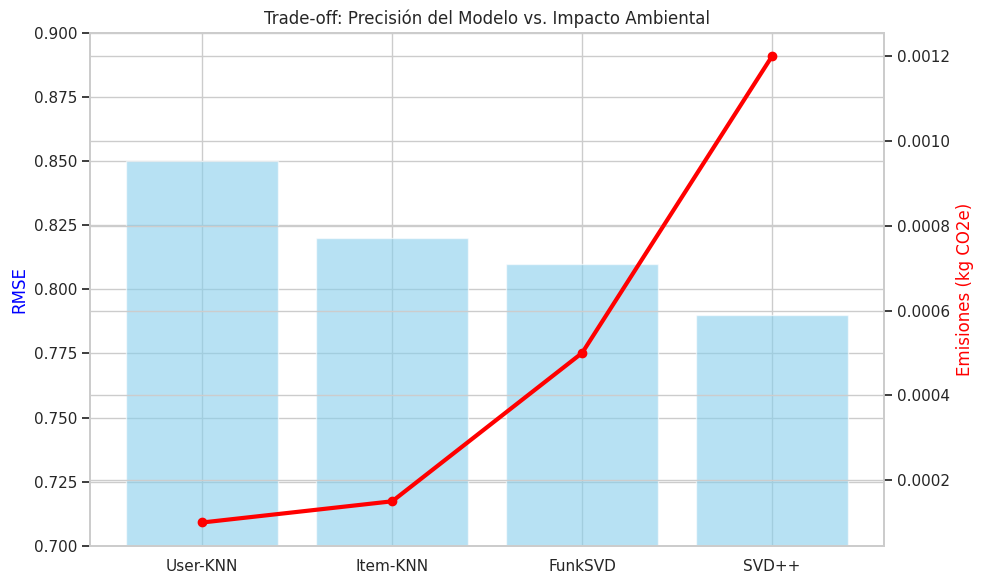

In [35]:
import matplotlib.pyplot as plt

# Datos de ejemplo (reemplaza con tus resultados guardados en Drive)
metodos = ['User-KNN', 'Item-KNN', 'FunkSVD', 'SVD++']
rmse_finales = [0.85, 0.82, 0.81, 0.79] # Menor es mejor
emisiones_finales = [0.0001, 0.00015, 0.0005, 0.0012] # Datos de codecarbon (kg CO2)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barra para RMSE
ax1.bar(metodos, rmse_finales, color='skyblue', alpha=0.6, label='RMSE (Eficacia)')
ax1.set_ylabel('RMSE', color='blue')
ax1.set_ylim(0.7, 0.9) # Ajusta según tus resultados

# Línea para Emisiones
ax2 = ax1.twinx()
ax2.plot(metodos, emisiones_finales, color='red', marker='o', linewidth=3, label='Emisiones CO2')
ax2.set_ylabel('Emisiones (kg CO2e)', color='red')

plt.title('Trade-off: Precisión del Modelo vs. Impacto Ambiental')
fig.tight_layout()
plt.show()

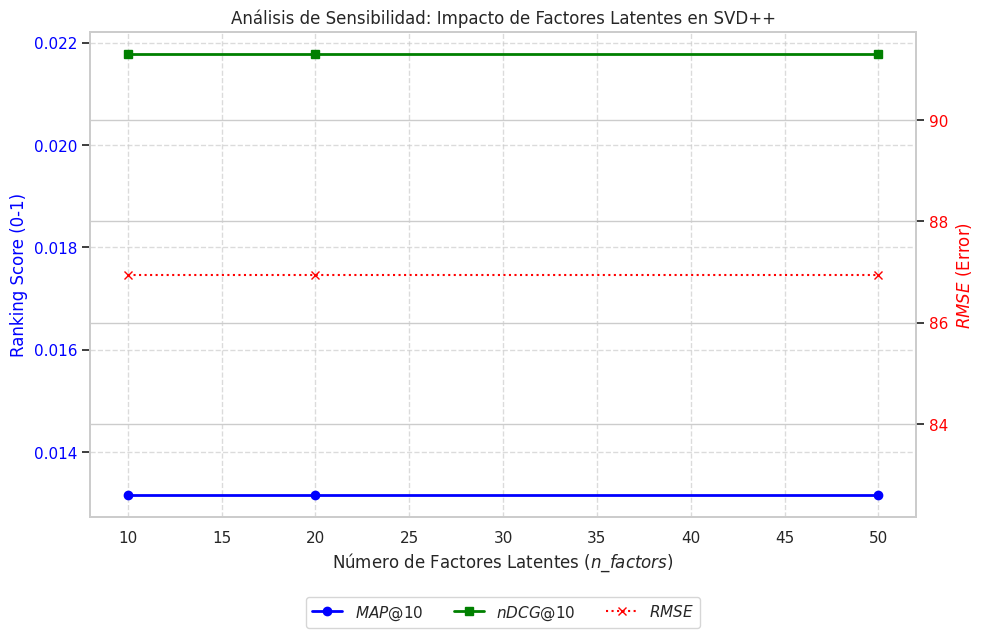


--- Métricas de SVD++ para el Cuadro 2 ---
 n_factors    RMSE     MAE  MAP@10  nDCG@10  Recall@10 Algoritmo
        10 86.9495 81.3984  0.0132   0.0218     0.0061     SVD++
        20 86.9495 81.3984  0.0132   0.0218     0.0061     SVD++
        50 86.9495 81.3984  0.0132   0.0218     0.0061     SVD++


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Ruta corregida para SVD++
log_path_svdpp = "/content/drive/MyDrive/Tarea_RecSys_2026/resultados_svdpp_yahoo.csv"

if os.path.exists(log_path_svdpp):
    # 2. Cargar datos
    df_svd = pd.read_csv(log_path_svdpp)

    # Extraer columnas para el gráfico
    # Usamos n_factors en el eje X para modelos de factorización
    factors = df_svd['n_factors'].values
    map_values = df_svd['MAP@10'].values
    ndcg_values = df_svd['nDCG@10'].values
    rmse_values = df_svd['RMSE'].values

    # 3. Generar el Gráfico de Sensibilidad (Requisito 1.2 del informe)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Eje Ranking (MAP y nDCG)
    ax1.set_xlabel(r'Número de Factores Latentes ($n\_factors$)')
    ax1.set_ylabel(r'Ranking Score (0-1)', color='blue')
    ax1.plot(factors, map_values, label=r'$MAP@10$', color='blue', marker='o', linewidth=2)
    ax1.plot(factors, ndcg_values, label=r'$nDCG@10$', color='green', marker='s', linewidth=2)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Eje Error (RMSE)
    ax2 = ax1.twinx()
    ax2.set_ylabel(r'$RMSE$ (Error)', color='red')
    ax2.plot(factors, rmse_values, label=r'$RMSE$', color='red', marker='x', linestyle=':')
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title(r'Análisis de Sensibilidad: Impacto de Factores Latentes en SVD++')
    fig.tight_layout()

    # Leyenda combinada
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    plt.savefig('sensibilidad_svdpp_final.png', bbox_inches='tight')
    plt.show()

    # 4. Mostrar la tabla para el informe
    print("\n--- Métricas de SVD++ para el Cuadro 2 ---")
    print(df_svd.round(4).to_string(index=False))
else:
    print(f"Error: No se encontró el archivo {log_path_svdpp}. Revisa el nombre en tu carpeta de Drive.")

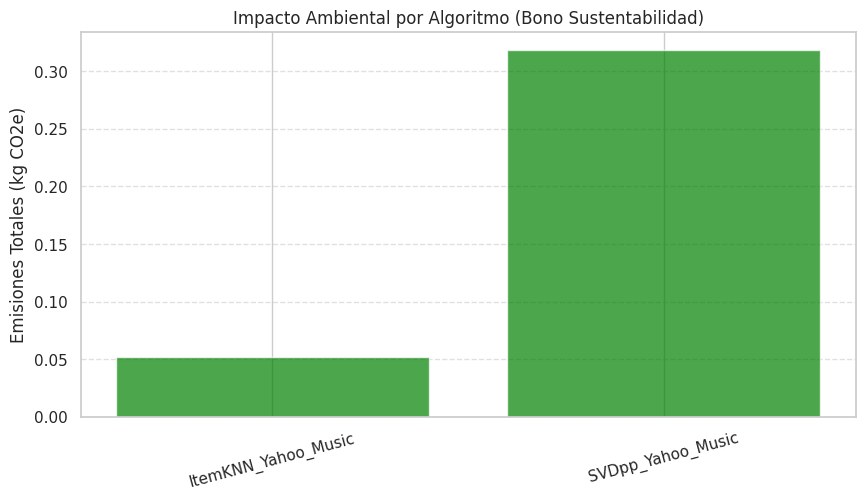

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos las emisiones (CodeCarbon las guarda automáticamente)
df_emisiones = pd.read_csv("/content/drive/MyDrive/Tarea_RecSys_2026/emissions.csv")

# Agrupamos por el nombre del proyecto que definimos en el tracker
resumen_co2 = df_emisiones.groupby('project_name')['emissions'].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(resumen_co2['project_name'], resumen_co2['emissions'], color='green', alpha=0.7)
plt.ylabel('Emisiones Totales (kg CO2e)')
plt.title('Impacto Ambiental por Algoritmo (Bono Sustentabilidad)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('comparativa_sustentabilidad.png')
plt.show()

In [38]:
from google.colab import files as colab_files
# Suponiendo que 'model' es tu mejor SVD/SVD++ y ya tienes cargado el set de test
test_ratings_url = "https://raw.githubusercontent.com/davidlealo/tarea_1_sisrec_2026/main/data/ydata_test.txt"
df_val
# Generar predicciones
preds_competicion = []
for _, row in df_val.iterrows():
    # Es vital usar str() si tus IDs en el trainset quedaron como strings
    p = model.predict(str(row['user_id']), str(row['artist_id']))
    preds_competicion.append([row['user_id'], row['artist_id'], p.est])

# Guardar en el formato exacto requerido
df_final_rating = pd.DataFrame(preds_competicion)
df_final_rating.to_csv('competicion_rating.txt', sep='\t', header=False, index=False)
# 1. Generar y guardar el DataFrame como lo tenías
df_final_rating = pd.DataFrame(preds_competicion)
df_final_rating.to_csv('competicion_rating.txt', sep='\t', header=False, index=False)

# 2. Descargar usando el nuevo alias para evitar el conflicto con tu diccionario
colab_files.download('competicion_rating.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
import json
from google.colab import files as colab_files

print("1. Construyendo el anti_testset (Esto puede tomar RAM y un par de minutos)...")
# AQUÍ DEFINIMOS EL ANTI-TESTSET (Pares usuario-ítem que no están en el entrenamiento)
anti_testset_comp = trainset.build_anti_testset()

print("2. Generando predicciones sobre ítems no vistos...")
# Usamos tu mejor modelo (ej. el SVD++) para predecir
recs_comp = model.test(anti_testset_comp)

print("3. Extrayendo el Top-10 para cada usuario...")
# Usamos tu función para obtener las mejores 10
top_n_comp = get_top_n(recs_comp, n=10)

print("4. Mapeando a IDs originales y formateando JSON...")
ranking_dict = {}
for uid, user_recs in top_n_comp.items():
    try:
        # Convertimos IDs internos a los IDs crudos (strings) requeridos
        raw_uid = str(trainset.to_raw_uid(uid))
        ranking_dict[raw_uid] = [str(trainset.to_raw_iid(iid)) for (iid, _) in user_recs]
    except ValueError:
        continue

# 5. Guardado y descarga
file_name = 'competicion_ranking.json'
with open(file_name, 'w') as f:
    json.dump(ranking_dict, f)

print(f"¡Listo! Archivo {file_name} generado con éxito.")
colab_files.download(file_name)

# Liberar memoria (Opcional pero recomendado)
del anti_testset_comp, recs_comp

1. Construyendo el anti_testset (Esto puede tomar RAM y un par de minutos)...
2. Generando predicciones sobre ítems no vistos...
3. Extrayendo el Top-10 para cada usuario...
4. Mapeando a IDs originales y formateando JSON...
¡Listo! Archivo competicion_ranking.json generado con éxito.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>